# Лабораторная работа №3

---
## Импорты и подготовка данных

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### Загрузка Fashion-MNIST

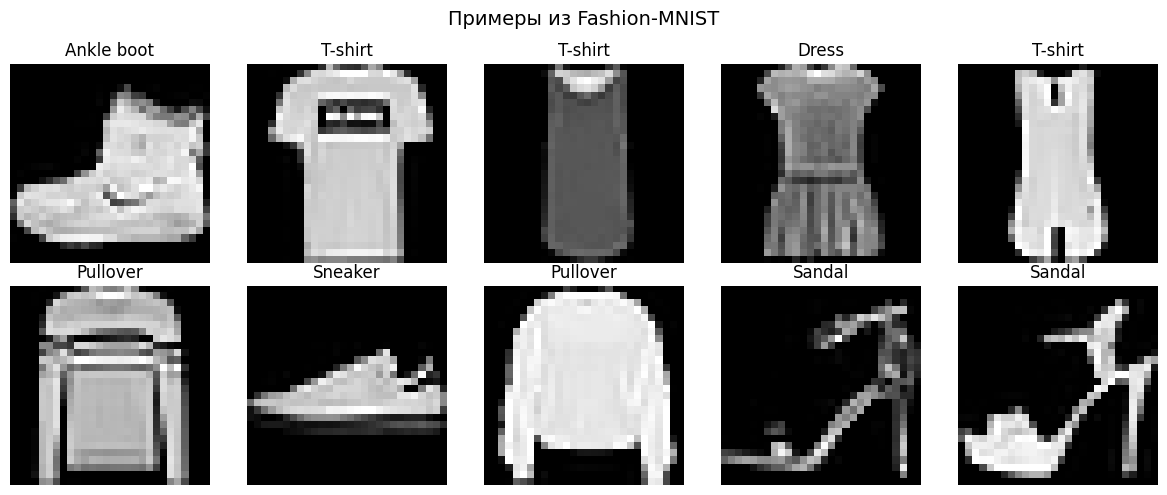

Train: 60000, Test: 10000
Image shape: torch.Size([1, 28, 28])


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='DATA', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='DATA', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Примеры из Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')

### Функция обучения и оценки

In [3]:
def train_model(model, train_loader, test_loader, epochs=20, lr=0.001, weight_decay=0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(correct / total)

        # --- Test ---
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += images.size(0)

        history['test_loss'].append(total_loss / total)
        history['test_acc'].append(correct / total)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d} | '
                  f'Train loss: {history["train_loss"][-1]:.4f}, acc: {history["train_acc"][-1]:.4f} | '
                  f'Test loss: {history["test_loss"][-1]:.4f}, acc: {history["test_acc"][-1]:.4f}')

    return history

---
## Задание 1. MLP + ReLU + регуляризация

Полносвязная сеть (Multi-Layer Perceptron):
- Вход: 784 нейрона (28×28 пикселей, развёрнутых в вектор)
- Скрытый слой 1: 512 нейронов, ReLU, BatchNorm, Dropout(0.3)
- Скрытый слой 2: 256 нейронов, ReLU, BatchNorm, Dropout(0.3)
- Выход: 10 нейронов (по одному на класс)

In [4]:
class MLP_ReLU_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

model1 = MLP_ReLU_Reg().to(device)
print(model1)
total_params = sum(p.numel() for p in model1.parameters())
print(f'\nВсего параметров: {total_params:,}')

MLP_ReLU_Reg(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=10, bias=True)
  )
)

Всего параметров: 537,354


In [5]:
history1 = train_model(model1, train_loader, test_loader, epochs=20, lr=0.001, weight_decay=1e-4)

Epoch  5 | Train loss: 0.3096, acc: 0.8854 | Test loss: 0.3430, acc: 0.8768
Epoch 10 | Train loss: 0.2655, acc: 0.9003 | Test loss: 0.3303, acc: 0.8802
Epoch 15 | Train loss: 0.2397, acc: 0.9110 | Test loss: 0.3117, acc: 0.8892
Epoch 20 | Train loss: 0.2217, acc: 0.9163 | Test loss: 0.2939, acc: 0.8946


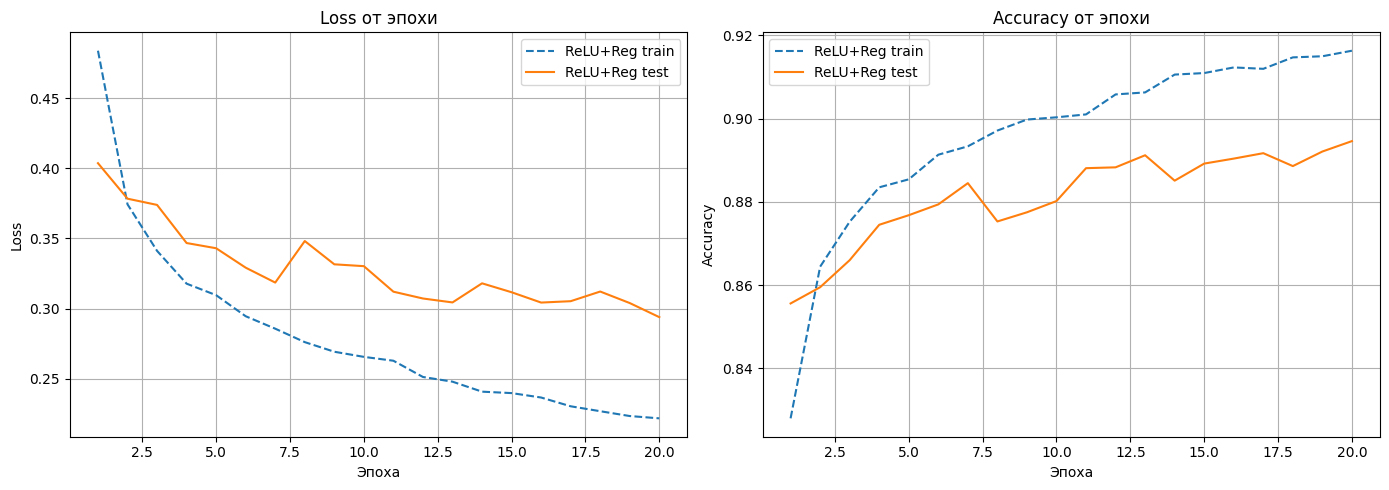

Итоговая точность на тесте: 0.8946


In [6]:
def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(histories[0]['train_loss']) + 1)

    for h, label in zip(histories, labels):
        axes[0].plot(epochs, h['train_loss'], '--', label=f'{label} train')
        axes[0].plot(epochs, h['test_loss'], '-', label=f'{label} test')
    axes[0].set_title('Loss от эпохи')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    for h, label in zip(histories, labels):
        axes[1].plot(epochs, h['train_acc'], '--', label=f'{label} train')
        axes[1].plot(epochs, h['test_acc'], '-', label=f'{label} test')
    axes[1].set_title('Accuracy от эпохи')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history([history1], ['ReLU+Reg'])
print(f'Итоговая точность на тесте: {history1["test_acc"][-1]:.4f}')

---
## Задание 2. MLP + ReLU БЕЗ регуляризации

Убираем Dropout, BatchNorm и weight_decay.

In [7]:
class MLP_ReLU_NoReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

model2 = MLP_ReLU_NoReg().to(device)
history2 = train_model(model2, train_loader, test_loader, epochs=20, lr=0.001, weight_decay=0)

Epoch  5 | Train loss: 0.2758, acc: 0.8978 | Test loss: 0.3329, acc: 0.8800
Epoch 10 | Train loss: 0.2078, acc: 0.9221 | Test loss: 0.3459, acc: 0.8853
Epoch 15 | Train loss: 0.1575, acc: 0.9413 | Test loss: 0.3794, acc: 0.8836
Epoch 20 | Train loss: 0.1254, acc: 0.9523 | Test loss: 0.3859, acc: 0.8923


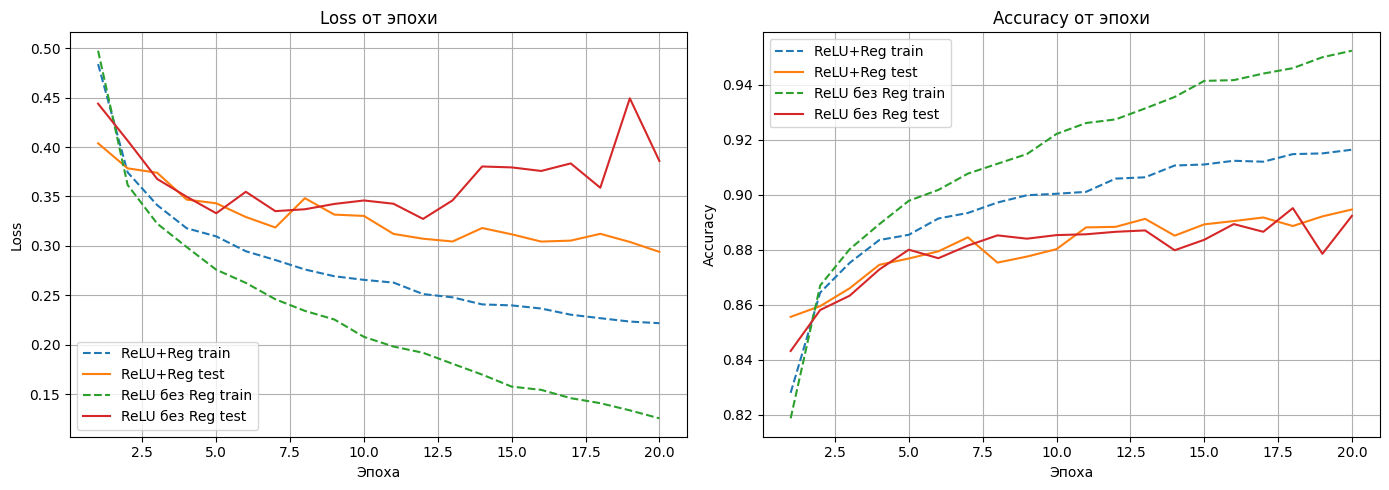

С регуляризацией   - test acc: 0.8946, train-test gap: 0.0217
Без регуляризации  - test acc: 0.8923, train-test gap: 0.0600


In [16]:
plot_history([history1, history2], ['ReLU+Reg', 'ReLU без Reg'])

print(f'С регуляризацией   - test acc: {history1["test_acc"][-1]:.4f}, train-test gap: {history1["train_acc"][-1] - history1["test_acc"][-1]:.4f}')
print(f'Без регуляризации  - test acc: {history2["test_acc"][-1]:.4f}, train-test gap: {history2["train_acc"][-1] - history2["test_acc"][-1]:.4f}')

**Вывод:** без регуляризации разрыв (gap) между train и test accuracy больше - модель переобучается.

---
## Задание 3. MLP + Sigmoid вместо ReLU

In [9]:
class MLP_Sigmoid_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

model3 = MLP_Sigmoid_Reg().to(device)
history3 = train_model(model3, train_loader, test_loader, epochs=20, lr=0.001, weight_decay=1e-4)

Epoch  5 | Train loss: 0.4526, acc: 0.8399 | Test loss: 0.4351, acc: 0.8423
Epoch 10 | Train loss: 0.4188, acc: 0.8491 | Test loss: 0.4115, acc: 0.8478
Epoch 15 | Train loss: 0.3911, acc: 0.8585 | Test loss: 0.3810, acc: 0.8610
Epoch 20 | Train loss: 0.3752, acc: 0.8635 | Test loss: 0.3791, acc: 0.8639


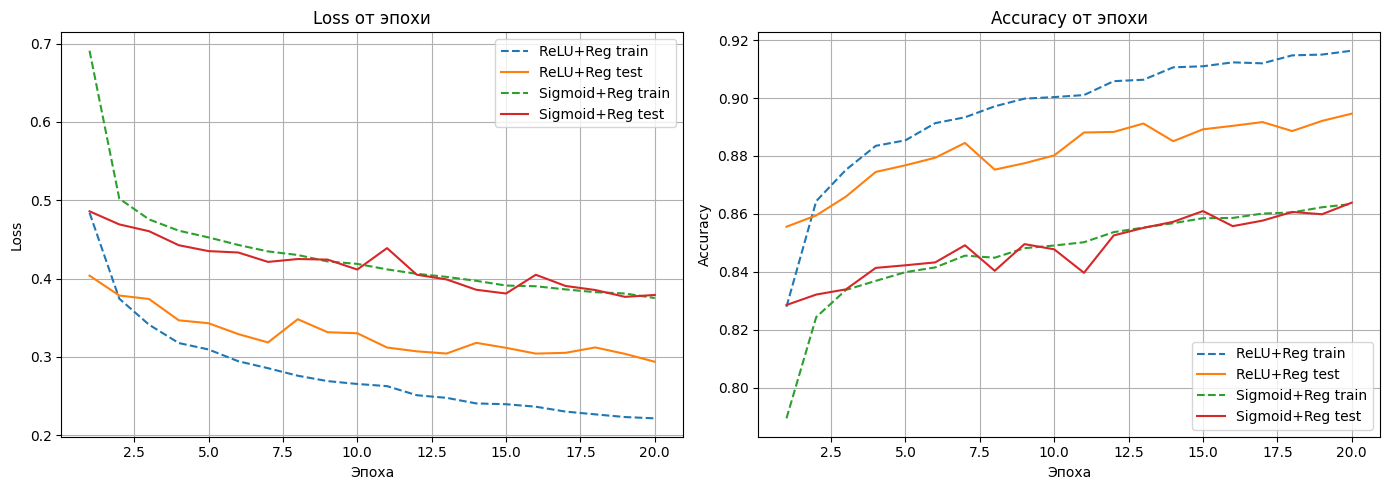

ReLU    - test acc: 0.8946
Sigmoid - test acc: 0.8639


In [15]:
plot_history([history1, history3], ['ReLU+Reg', 'Sigmoid+Reg'])

print(f'ReLU    - test acc: {history1["test_acc"][-1]:.4f}')
print(f'Sigmoid - test acc: {history3["test_acc"][-1]:.4f}')

**Вывод:** Sigmoid-модель обучается медленнее и достигает более низкой точности. Причина - затухание градиентов: при обратном распространении через Sigmoid градиенты быстро уменьшаются, и ранние слои сети почти не обновляются. ReLU решает эту проблему, пропуская градиент без изменений для положительных значений.

---
## Задание 4. CNN + визуализация активаций

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

model_cnn = SimpleCNN().to(device)
print(model_cnn)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f'\nВсего параметров: {total_params:,}')

SimpleCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Всего параметров: 206,922


Epoch  5 | Train loss: 0.2661, acc: 0.9026 | Test loss: 0.2646, acc: 0.9010
Epoch 10 | Train loss: 0.2000, acc: 0.9254 | Test loss: 0.2409, acc: 0.9118
Epoch 15 | Train loss: 0.1583, acc: 0.9395 | Test loss: 0.2328, acc: 0.9191
Epoch 20 | Train loss: 0.1257, acc: 0.9524 | Test loss: 0.2482, acc: 0.9193


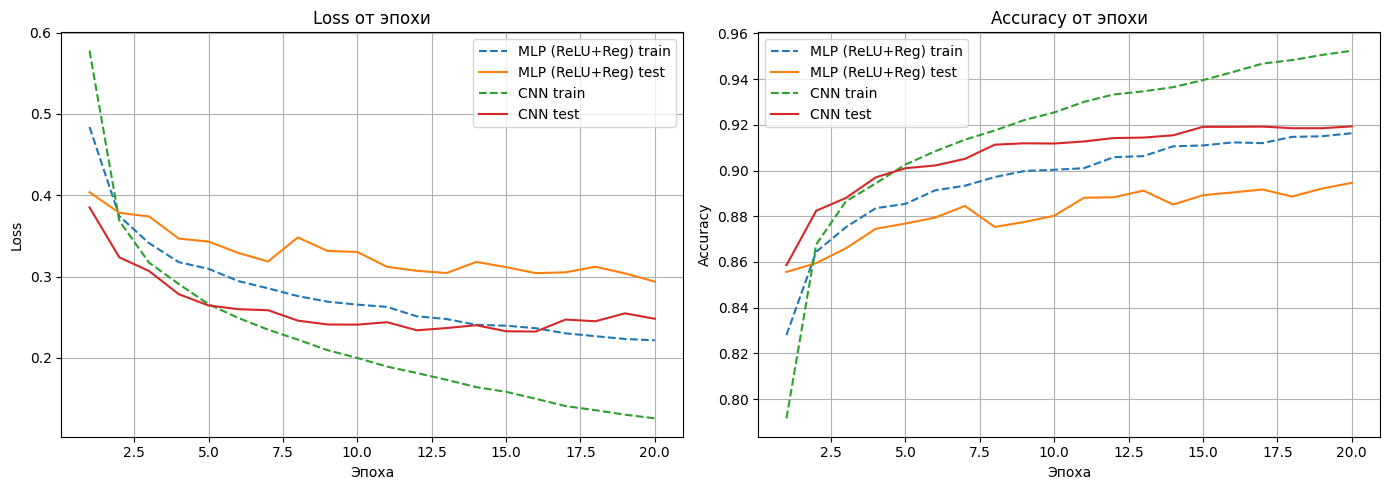

MLP — test acc: 0.8946
CNN — test acc: 0.9193


In [12]:
history_cnn = train_model(model_cnn, train_loader, test_loader, epochs=20, lr=0.001)

plot_history([history1, history_cnn], ['MLP (ReLU+Reg)', 'CNN'])

print(f'MLP — test acc: {history1["test_acc"][-1]:.4f}')
print(f'CNN — test acc: {history_cnn["test_acc"][-1]:.4f}')

### Визуализация активаций первых свёрточных слоёв

Пропустим одно изображение через сеть и посмотрим, что "видят" фильтры первого и второго свёрточных слоёв.

- **Первый слой** обычно находит простые паттерны: горизонтальные/вертикальные границы, углы, текстуры
- **Второй слой** комбинирует простые паттерны в более сложные: контуры, формы

Изображение: Ankle boot
Активации conv1: (16, 14, 14) (16 карт 14x14)
Активации conv2: (32, 7, 7) (32 карты 7x7)


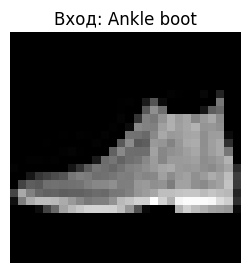

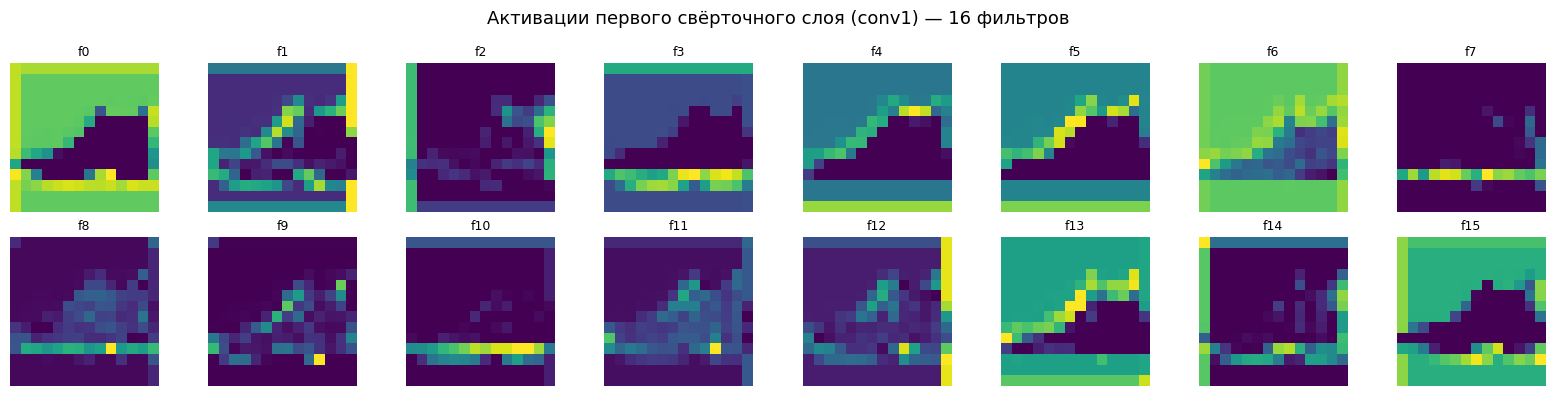

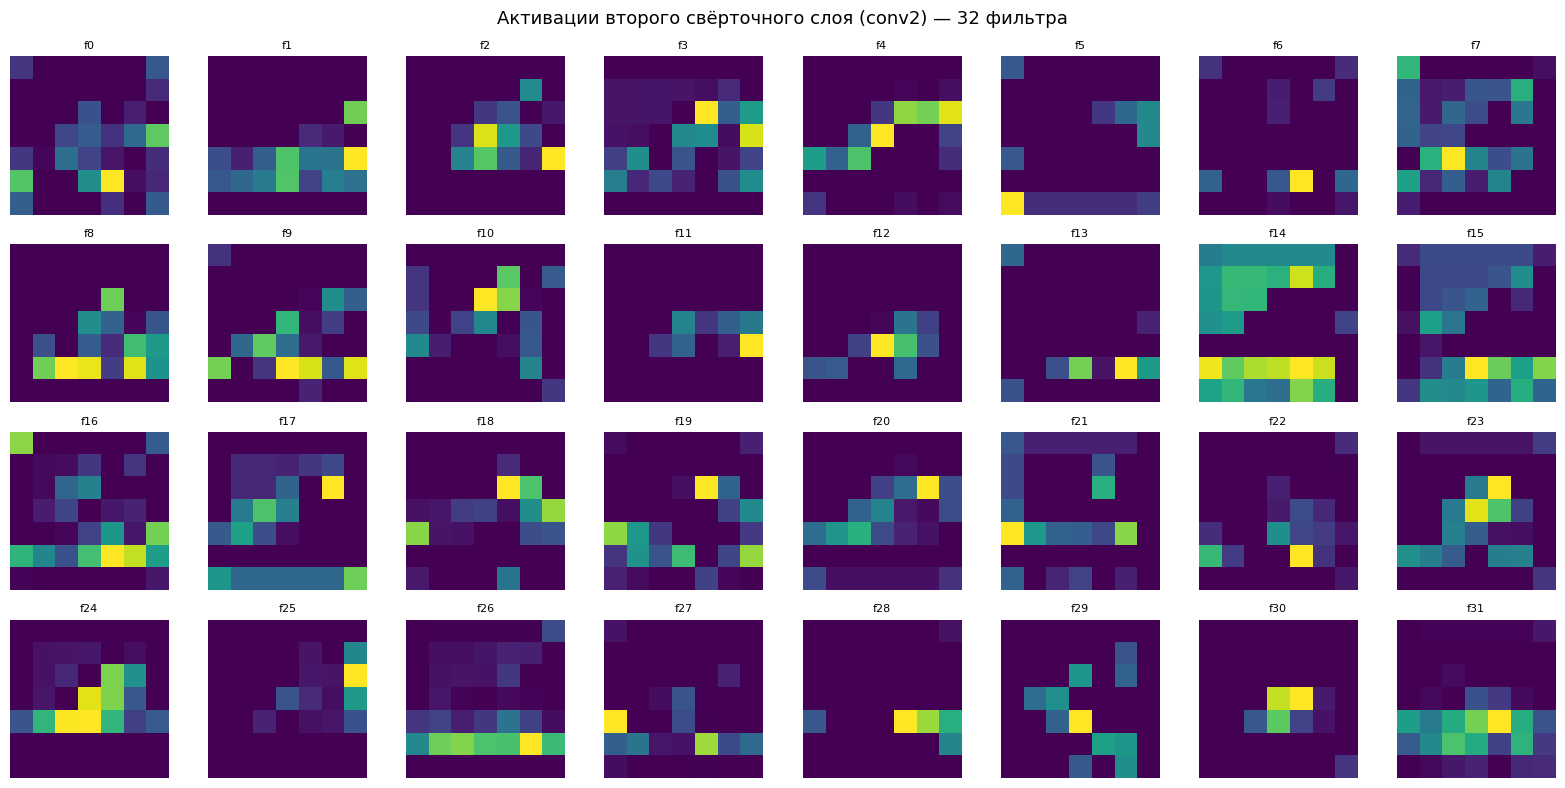

In [13]:
img, label = test_dataset[0]
img_input = img.unsqueeze(0).to(device)

model_cnn.eval()
with torch.no_grad():
    act1 = model_cnn.conv1(img_input)
    act2 = model_cnn.conv2(act1)

act1 = act1.squeeze().cpu().numpy()
act2 = act2.squeeze().cpu().numpy()

print(f'Изображение: {class_names[label]}')
print(f'Активации conv1: {act1.shape} (16 карт 14x14)')
print(f'Активации conv2: {act2.shape} (32 карты 7x7)')

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(img.squeeze(), cmap='gray')
ax.set_title(f'Вход: {class_names[label]}')
ax.axis('off')
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(act1[i], cmap='viridis')
    ax.set_title(f'f{i}', fontsize=9)
    ax.axis('off')
plt.suptitle('Активации первого свёрточного слоя (conv1) — 16 фильтров', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act2[i], cmap='viridis')
    ax.set_title(f'f{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Активации второго свёрточного слоя (conv2) — 32 фильтра', fontsize=13)
plt.tight_layout()
plt.show()

**Что видно на активациях:**
- **Conv1** — фильтры реагируют на базовые элементы: края, границы.
- **Conv2** — более абстрактные признаки: комбинации границ, контуры объекта целиком.

Это подтверждает принцип работы CNN: ранние слои -> простые признаки, глубокие слои -> сложные комбинации.

---
## Сравнительная таблица всех моделей

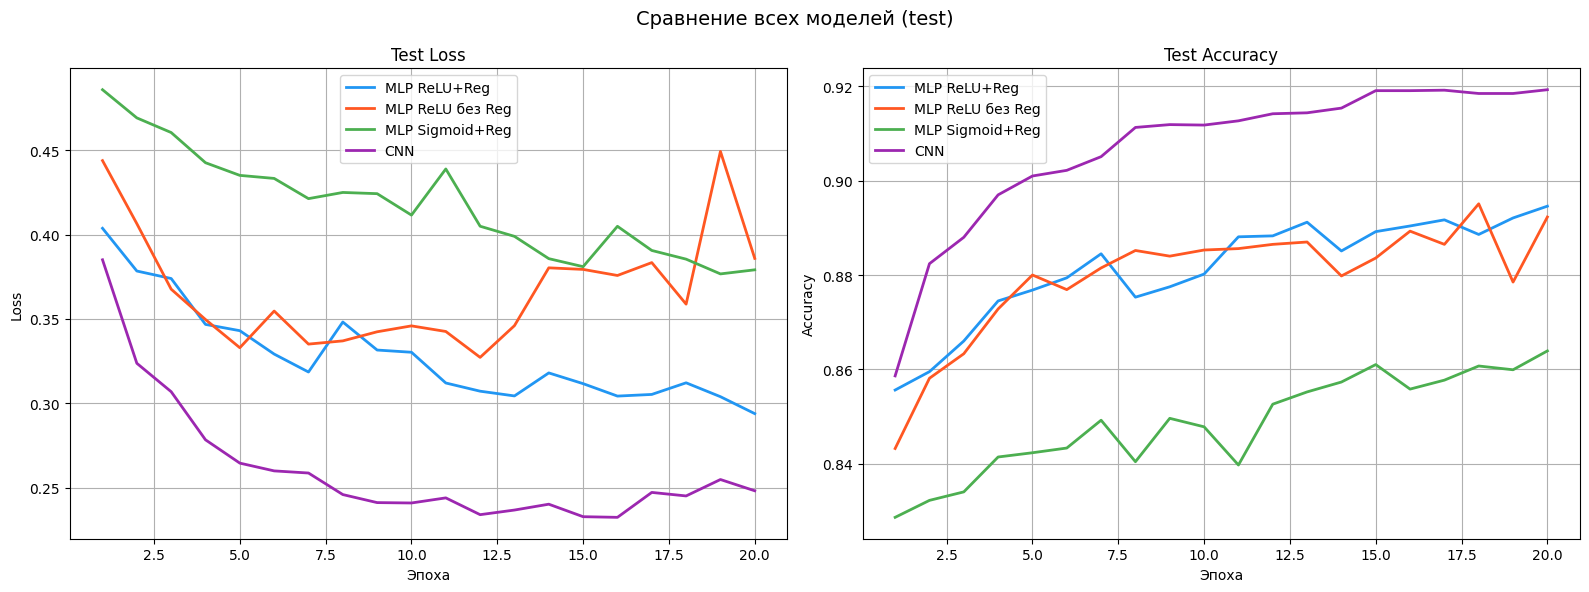

Итоговая точность на тесте:
  MLP ReLU+Reg              — 0.8946
  MLP ReLU без Reg          — 0.8923
  MLP Sigmoid+Reg           — 0.8639
  CNN                       — 0.9193


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, 21)

names = ['MLP ReLU+Reg', 'MLP ReLU без Reg', 'MLP Sigmoid+Reg', 'CNN']
hists = [history1, history2, history3, history_cnn]
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for h, name, c in zip(hists, names, colors):
    axes[0].plot(epochs, h['test_loss'], '-', label=name, color=c, linewidth=2)
axes[0].set_title('Test Loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

for h, name, c in zip(hists, names, colors):
    axes[1].plot(epochs, h['test_acc'], '-', label=name, color=c, linewidth=2)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Сравнение всех моделей (test)', fontsize=14)
plt.tight_layout()
plt.show()

print('Итоговая точность на тесте:')
for name, h in zip(names, hists):
    print(f'  {name:25s} — {h["test_acc"][-1]:.4f}')